# Pneumonia Classification from Chest X-ray Images
## Using Transfer Learning with ResNet18

**Course:** CT223H — Nen tang tri tue nhan tao

---

**Research Questions:**

1. How effectively can a pretrained ResNet18 model distinguish between normal and pneumonia chest X-ray images?
2. How does transfer learning affect pneumonia classification performance compared with training ResNet18 from scratch?

---

| Item | Detail |
|---|---|
| **Task** | Binary Image Classification |
| **Classes** | NORMAL (0), PNEUMONIA (1) |
| **Model** | ResNet18 (pretrained ImageNet) |
| **Dataset** | Kermany Chest X-ray Pneumonia Dataset |
| **Input** | 224 x 224 RGB |
| **Framework** | PyTorch + torchvision |

---
## 0. Environment Setup

In [4]:
# Kiem tra GPU
!nvidia-smi

Tue Sep 15 07:37:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Cai dat thu vien (Colab thuong da co san phan lon)
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas pillow tqdm

In [6]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

from PIL import Image
from tqdm.auto import tqdm

# Thiet lap style cho bieu do
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [7]:
# ===== Reproducibility =====
SEED = 42

def seed_everything(seed=SEED):
    """Set seed cho tat ca random generators de ket qua co the tai tao."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

---
## 1. Download Dataset tu Kaggle

Dataset: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

Co 2 cach de xac thuc Kaggle API:
1. **Cach 1A (Bao mat & Khuyen nghi):** Tu dong nap tu file `.env` hoac bien moi truong `KAGGLE_USERNAME` va `KAGGLE_KEY` (khong lo key trong code).
2. **Cach 1B (Upload file):** Tren trang Kaggle Settings, cuon xuong muc **Legacy API Credentials** -> bam nut **Create Legacy API Key** de tai file `kaggle.json`, sau do upload len Colab.
3. **Cach 2 (Du phong):** Download thu cong tu Kaggle, upload zip len Google Drive, mount Drive.


In [ ]:
# ===== CACH 1: Cau hinh Kaggle API =====
import os
import json

# --- TUY CHON A: Tu dong nap tu file .env hoac bien moi truong ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    # Neu chay tren Google Colab chua cai python-dotenv, doc truc tiep file .env neu co
    if os.path.exists(".env"):
        with open(".env", "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    k, v = line.split("=", 1)
                    os.environ[k.strip()] = v.strip().strip('"\'')

# Lay Username va API Key/Token tu bien moi truong
KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME", "").strip()
KAGGLE_KEY      = os.getenv("KAGGLE_KEY", "").strip()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")

if KAGGLE_USERNAME and KAGGLE_KEY:
    with open(kaggle_json_path, "w", encoding="utf-8") as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
    os.chmod(kaggle_json_path, 0o600)
    print(f"✅ Da cau hinh ~/.kaggle/kaggle.json thanh cong tu .env cho user: {KAGGLE_USERNAME}!")
elif os.path.exists(kaggle_json_path):
    print("✅ Tim thay file ~/.kaggle/kaggle.json da co san tren he thong!")
else:
    # --- TUY CHON B: Upload file kaggle.json (Neu chua cau hinh .env) ---
    print("Chua tim thay thong tin trong .env. Dang cho ban upload file kaggle.json...")
    print("👉 Tip: Tren trang Kaggle, bam nut 'Create Legacy API Key' (o muc Legacy API Credentials) de tai file kaggle.json")
    try:
        from google.colab import files
        uploaded = files.upload()
        if 'kaggle.json' in uploaded:
            !mv kaggle.json ~/.kaggle/
            !chmod 600 ~/.kaggle/kaggle.json
            print("✅ Kaggle API key da duoc cau hinh thanh cong!")
        else:
            print("⚠️ Chua upload dung file kaggle.json. Vui long kiem tra lai.")
    except Exception as e:
        print(f"⚠️ Vui long tao file .env hoac ~/.kaggle/kaggle.json: {e}")


In [9]:
# Download dataset tu Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data --unzip
print('Dataset da tai xong!')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:16<00:00, 150MB/s] 

Dataset da tai xong!


In [10]:
# ===== CACH 2 (Backup): Dung Google Drive =====
# Neu cach 1 khong hoat dong, uncomment block duoi:

# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/drive/MyDrive/chest-xray-pneumonia.zip /content/data/
# !cd /content/data && unzip -q chest-xray-pneumonia.zip
# print('Dataset da giai nen tu Google Drive!')

In [11]:
# Xac dinh duong dan dataset
DATA_DIR = Path('/content/data/chest_xray')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

# Kiem tra cau truc
print('Cau truc dataset:')
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f'\n{split_dir.name}/')
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            n_images = len(list(class_dir.glob('*')))
            print(f'  +-- {class_dir.name}: {n_images} images')

Cau truc dataset:

train/
  +-- NORMAL: 1341 images
  +-- PNEUMONIA: 3875 images

val/
  +-- NORMAL: 8 images
  +-- PNEUMONIA: 8 images

test/
  +-- NORMAL: 234 images
  +-- PNEUMONIA: 390 images


---
## 2. Exploratory Data Analysis (EDA)

In [12]:
# ===== Dem so luong anh chinh xac =====
def count_images(data_dir):
    """Dem so luong anh trong moi class cua mot split."""
    counts = {}
    for class_dir in sorted(Path(data_dir).iterdir()):
        if class_dir.is_dir():
            exts = ['*.jpeg', '*.jpg', '*.png', '*.JPEG', '*.JPG', '*.PNG']
            n = sum(len(list(class_dir.glob(ext))) for ext in exts)
            counts[class_dir.name] = n
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Tao bang tong hop
summary_data = {
    'Split': ['Train', 'Train', 'Validation', 'Validation', 'Test', 'Test'],
    'Class': list(train_counts.keys()) + list(val_counts.keys()) + list(test_counts.keys()),
    'Count': list(train_counts.values()) + list(val_counts.values()) + list(test_counts.values())
}
df_summary = pd.DataFrame(summary_data)

print('=' * 50)
print('DATASET SUMMARY')
print('=' * 50)
for split in ['Train', 'Validation', 'Test']:
    subset = df_summary[df_summary['Split'] == split]
    total = subset['Count'].sum()
    print(f'\n{split}: {total} images')
    for _, row in subset.iterrows():
        pct = row['Count'] / total * 100 if total > 0 else 0
        print(f'  {row["Class"]:>12s}: {row["Count"]:>5d} ({pct:.1f}%)')

total_all = df_summary['Count'].sum()
print(f'\n{"=" * 50}')
print(f'TOTAL: {total_all} images')
print(f'{"=" * 50}')

DATASET SUMMARY

Train: 5216 images
        NORMAL:  1341 (25.7%)
     PNEUMONIA:  3875 (74.3%)

Validation: 16 images
        NORMAL:     8 (50.0%)
     PNEUMONIA:     8 (50.0%)

Test: 624 images
        NORMAL:   234 (37.5%)
     PNEUMONIA:   390 (62.5%)

TOTAL: 5856 images


/tmp/ipykernel_348/3907959816.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


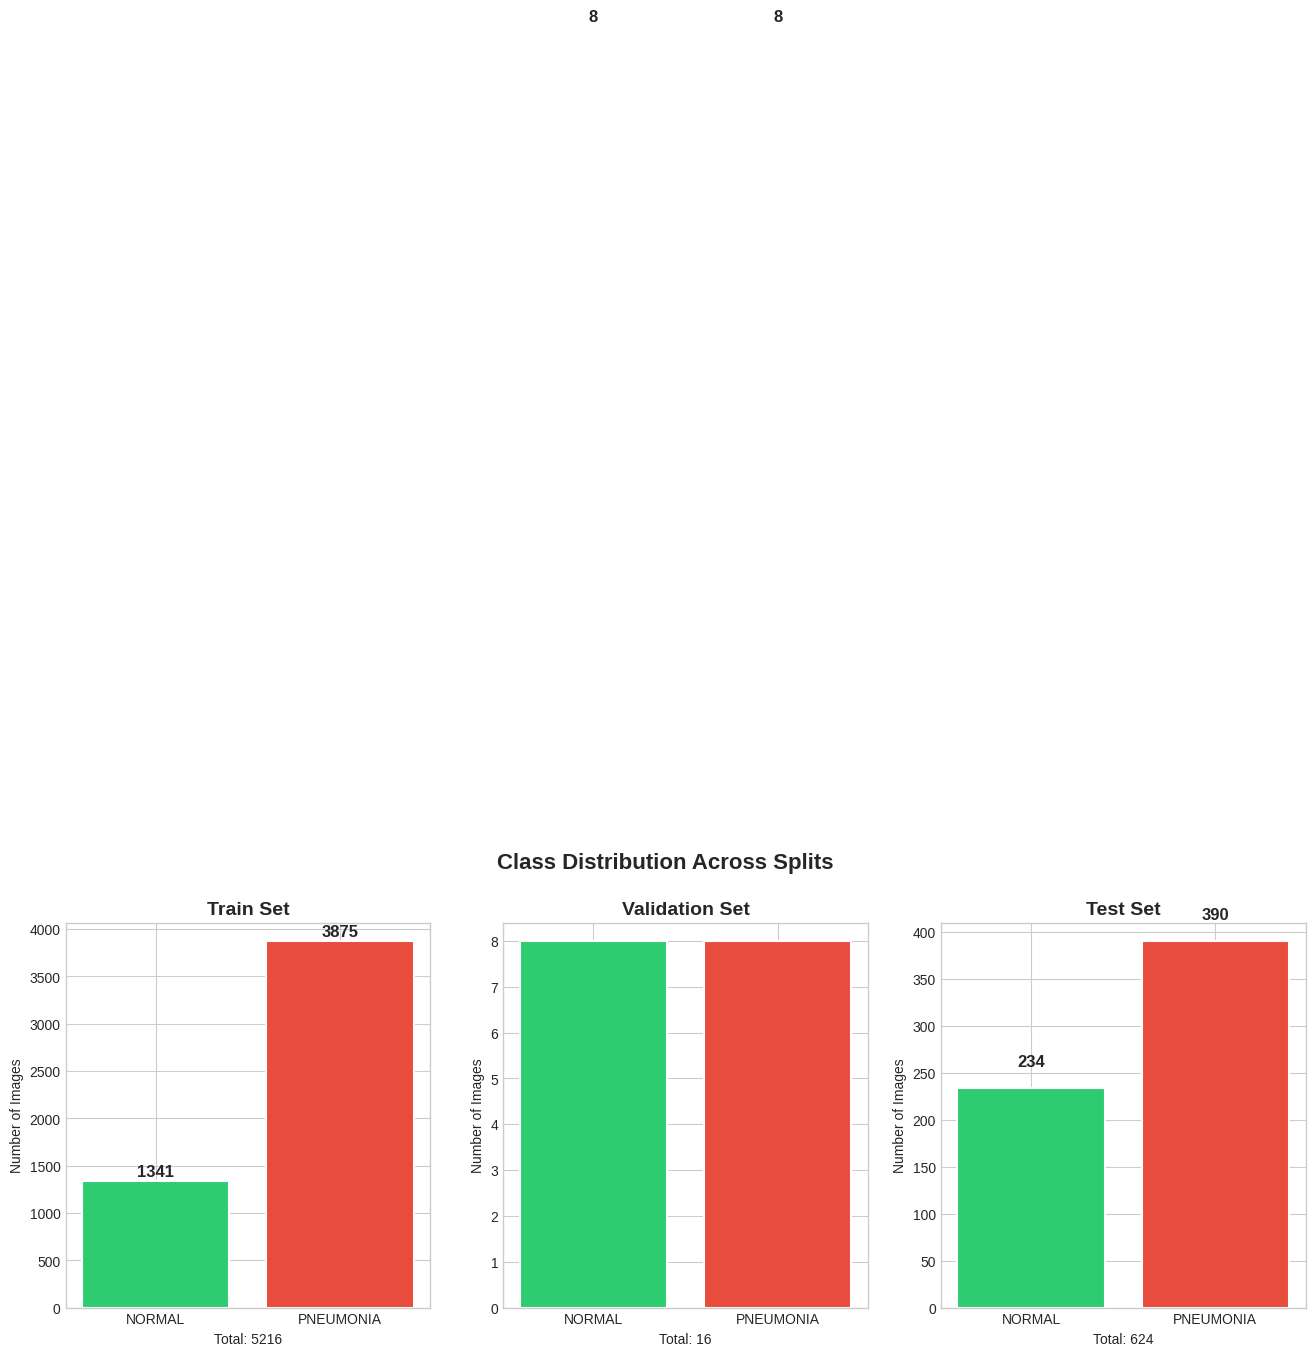

In [13]:
# ===== Bieu do phan phoi class =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

splits_data = [
    ('Train', train_counts),
    ('Validation', val_counts),
    ('Test', test_counts)
]

colors = ['#2ecc71', '#e74c3c']

for ax, (split_name, counts) in zip(axes, splits_data):
    classes = list(counts.keys())
    values = list(counts.values())
    bars = ax.bar(classes, values, color=colors, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax.set_title(f'{split_name} Set', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Images')
    total = sum(values)
    ax.set_xlabel(f'Total: {total}')

plt.suptitle('Class Distribution Across Splits', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('WARNING: Validation set chi co 16 images -> can re-split!')
print('WARNING: Train set bi mat can bang: PNEUMONIA ~ 74%, NORMAL ~ 26%')

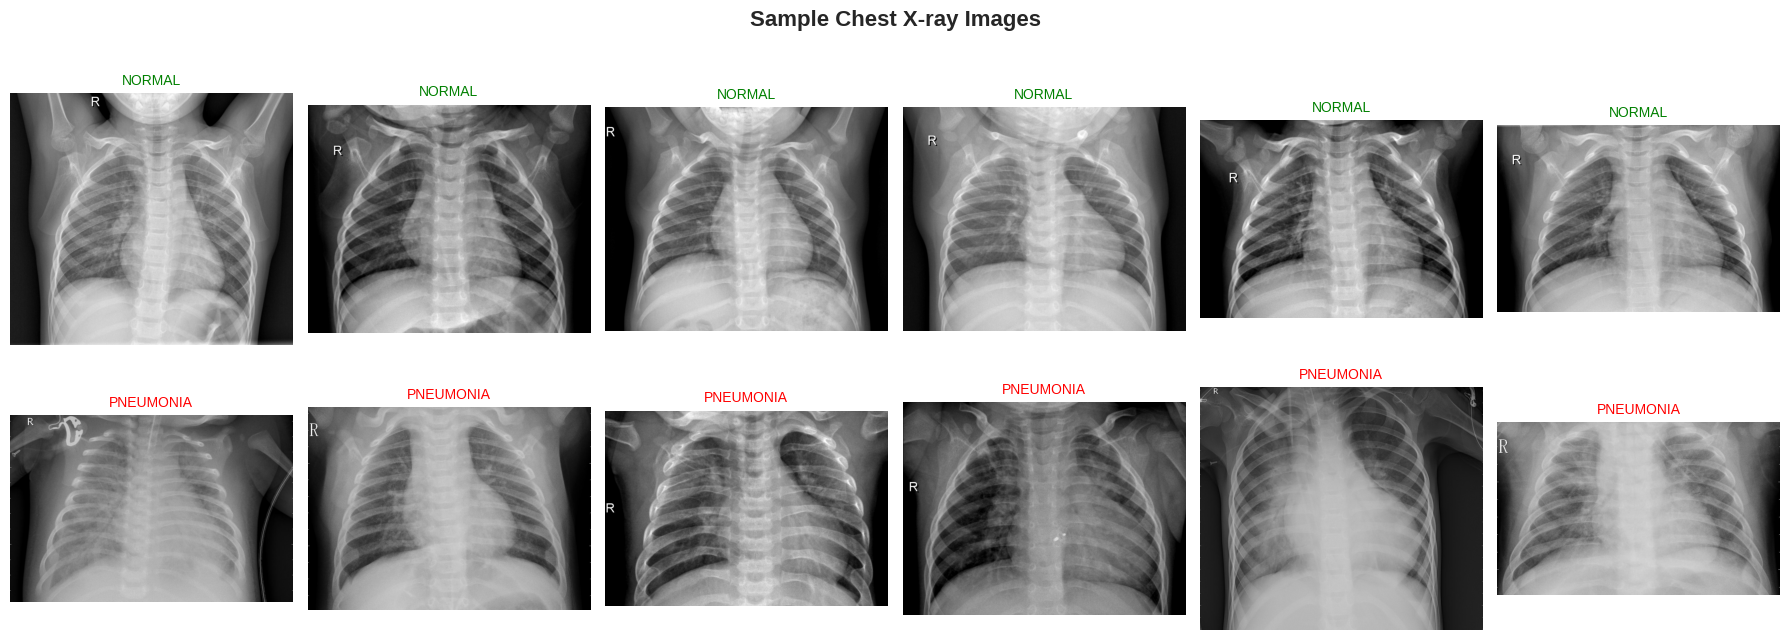

In [14]:
# ===== Hien thi anh mau =====
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for row, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    class_dir = TRAIN_DIR / class_name
    image_files = sorted(class_dir.glob('*.jpeg'))[:6]

    for col, img_path in enumerate(image_files):
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(class_name, fontsize=10,
                                  color='green' if class_name == 'NORMAL' else 'red')
        axes[row, col].axis('off')

plt.suptitle('Sample Chest X-ray Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ===== Phan tich kich thuoc anh goc =====
widths, heights = [], []

for class_name in ['NORMAL', 'PNEUMONIA']:
    class_dir = TRAIN_DIR / class_name
    for img_path in list(class_dir.glob('*.jpeg'))[:200]:
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f'Kich thuoc anh goc (sample):')
print(f'  Width  -- min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'  Height -- min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
print(f'\n-> Tat ca se duoc resize ve 224 x 224 cho ResNet18')

Kich thuoc anh goc (sample):
  Width  -- min: 437, max: 2844, mean: 1440
  Height -- min: 144, max: 2601, mean: 1112

-> Tat ca se duoc resize ve 224 x 224 cho ResNet18


---
## 3. Data Preprocessing & Re-splitting

### Van de:
- Validation set goc chi co **16 images** -> qua nho, khong tin cay
- Can **re-split**: gop Train + Val goc -> chia lai 85% Train / 15% Validation
- **Test set giu nguyen** (624 images)

### Xu ly class imbalance:
- Su dung **Weighted CrossEntropyLoss** voi class weights

In [16]:
# ===== Hyperparameters =====
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_EPOCHS     = 15
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-4
NUM_CLASSES    = 2
PATIENCE       = 4       # Early stopping patience
VAL_SPLIT      = 0.15    # 15% cho validation

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

print('Hyperparameters:')
print(f'  Image size:     {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size:     {BATCH_SIZE}')
print(f'  Epochs:         {NUM_EPOCHS}')
print(f'  Learning rate:  {LEARNING_RATE}')
print(f'  Weight decay:   {WEIGHT_DECAY}')
print(f'  Early stopping: patience={PATIENCE}')
print(f'  Val split:      {VAL_SPLIT*100:.0f}%')

Hyperparameters:
  Image size:     224x224
  Batch size:     32
  Epochs:         15
  Learning rate:  0.0001
  Weight decay:   0.0001
  Early stopping: patience=4
  Val split:      15%


In [17]:
# ===== Dinh nghia transforms =====

# Training: co data augmentation nhe
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(7),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation & Test: khong augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms da duoc dinh nghia')
print('\nLuu y: X-ray grayscale se duoc tu dong convert sang RGB')
print('(copy 1 channel -> 3 channels) trong Custom Dataset class')

Transforms da duoc dinh nghia

Luu y: X-ray grayscale se duoc tu dong convert sang RGB
(copy 1 channel -> 3 channels) trong Custom Dataset class


In [18]:
# ===== Re-split: Gop Train + Val goc -> chia lai =====

full_train_dataset = ImageFolder(str(TRAIN_DIR), transform=None)
full_val_dataset   = ImageFolder(str(VAL_DIR), transform=None)

# Gop tat ca file paths va labels
all_samples = full_train_dataset.samples + full_val_dataset.samples
all_paths   = [s[0] for s in all_samples]
all_labels  = [s[1] for s in all_samples]

print(f'Tong so anh (train + val goc): {len(all_samples)}')
print(f'   NORMAL:    {all_labels.count(0)}')
print(f'   PNEUMONIA: {all_labels.count(1)}')

# Stratified split: giu ty le class trong ca train va val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=VAL_SPLIT,
    stratify=all_labels,
    random_state=SEED
)

print(f'\nRe-split hoan tat:')
print(f'   New Train: {len(train_paths)} images')
print(f'     NORMAL:    {train_labels.count(0)} ({train_labels.count(0)/len(train_labels)*100:.1f}%)')
print(f'     PNEUMONIA: {train_labels.count(1)} ({train_labels.count(1)/len(train_labels)*100:.1f}%)')
print(f'   New Val:   {len(val_paths)} images')
print(f'     NORMAL:    {val_labels.count(0)} ({val_labels.count(0)/len(val_labels)*100:.1f}%)')
print(f'     PNEUMONIA: {val_labels.count(1)} ({val_labels.count(1)/len(val_labels)*100:.1f}%)')

Tong so anh (train + val goc): 5232
   NORMAL:    1349
   PNEUMONIA: 3883

Re-split hoan tat:
   New Train: 4447 images
     NORMAL:    1147 (25.8%)
     PNEUMONIA: 3300 (74.2%)
   New Val:   785 images
     NORMAL:    202 (25.7%)
     PNEUMONIA: 583 (74.3%)


---
### 📊 So sánh chi tiết: Số liệu Dataset Gốc vs. Sau khi Re-split (Trước khi huấn luyện)

#### 🔍 Tại sao bắt buộc phải so sánh và phân chia lại dữ liệu?
1. **Bất cập của cấu trúc gốc (Kermany et al.):**
   - Tập **Validation gốc chỉ có vỏn vẹn 16 ảnh** (8 NORMAL, 8 PNEUMONIA). Đây là điểm hạn chế chí mạng nếu dùng trực tiếp để huấn luyện:
     - Tập val quá nhỏ dẫn đến **độ biến động cực cao (High Variance)**: mỗi bức ảnh chiếm tới 6.25% accuracy. Khi đánh giá model qua từng epoch, loss và metrics sẽ dao động dữ dội.
     - Cơ chế **Early Stopping** và **Model Checkpoint** dựa vào Validation Loss/Accuracy sẽ bị đánh lừa bởi nhiễu ngẫu nhiên, dễ chọn nhầm model chưa tối ưu.
   - Tập **Test gốc gồm 624 ảnh** (234 NORMAL, 390 PNEUMONIA) từ nhóm bệnh nhân độc lập hoàn toàn, phải được **giữ nguyên 100%** nhằm đảm bảo tính khách quan y khoa khi đánh giá cuối cùng.
2. **Chiến lược phân chia lại khoa học (Data Splitting Strategy):**
   - Gộp tập Train gốc (5,216 ảnh) và Val gốc (16 ảnh) thành **5,232 ảnh**.
   - Sử dụng **Stratified Split 85% Train / 15% Validation** (với `random_state=SEED=42`).
   - Kết quả: Tập **Validation mới đạt ~785 ảnh** (đầy đủ ý nghĩa thống kê), đồng thời **tỷ lệ mất cân bằng nhãn gốc (~74.3% PNEUMONIA / ~25.7% NORMAL) được bảo toàn hoàn hảo** ở cả 2 tập.

In [19]:
# ===== 1. Bang so sanh dinh luong: Dataset Goc vs. Re-split (Truoc khi train) =====

# Thu thap so lieu goc tu train_counts, val_counts, test_counts da tinh o phan EDA
orig_train_norm = train_counts.get('NORMAL', 0)
orig_train_pneu = train_counts.get('PNEUMONIA', 0)
orig_train_total = orig_train_norm + orig_train_pneu

orig_val_norm = val_counts.get('NORMAL', 0)
orig_val_pneu = val_counts.get('PNEUMONIA', 0)
orig_val_total = orig_val_norm + orig_val_pneu

orig_test_norm = test_counts.get('NORMAL', 0)
orig_test_pneu = test_counts.get('PNEUMONIA', 0)
orig_test_total = orig_test_norm + orig_test_pneu

# Thu thap so lieu sau khi chia lai (Re-split)
new_train_norm = train_labels.count(0)
new_train_pneu = train_labels.count(1)
new_train_total = len(train_labels)

new_val_norm = val_labels.count(0)
new_val_pneu = val_labels.count(1)
new_val_total = len(val_labels)

new_test_norm = orig_test_norm
new_test_pneu = orig_test_pneu
new_test_total = orig_test_total

# Xay dung bang so sanh chi tiet
comparison_records = [
    {
        'Giai doan': '1. Dataset Goc (Original)',
        'Tap du lieu': 'Train',
        'NORMAL': orig_train_norm,
        'PNEUMONIA': orig_train_pneu,
        'Tong so anh': orig_train_total,
        'Ty le NORMAL (%)': round(orig_train_norm / orig_train_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(orig_train_pneu / orig_train_total * 100, 2),
        'Danh gia': 'Mat can bang (74.3% Pneumonia)'
    },
    {
        'Giai doan': '1. Dataset Goc (Original)',
        'Tap du lieu': 'Validation',
        'NORMAL': orig_val_norm,
        'PNEUMONIA': orig_val_pneu,
        'Tong so anh': orig_val_total,
        'Ty le NORMAL (%)': round(orig_val_norm / orig_val_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(orig_val_pneu / orig_val_total * 100, 2),
        'Danh gia': '⚠️ Qua it (16 anh) - Khong du tin cay'
    },
    {
        'Giai doan': '1. Dataset Goc (Original)',
        'Tap du lieu': 'Test',
        'NORMAL': orig_test_norm,
        'PNEUMONIA': orig_test_pneu,
        'Tong so anh': orig_test_total,
        'Ty le NORMAL (%)': round(orig_test_norm / orig_test_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(orig_test_pneu / orig_test_total * 100, 2),
        'Danh gia': 'Benh nhan doc lap (Benchmark chuan)'
    },
    {
        'Giai doan': '2. Sau Re-split (Chuan bi Train)',
        'Tap du lieu': 'Train (Moi)',
        'NORMAL': new_train_norm,
        'PNEUMONIA': new_train_pneu,
        'Tong so anh': new_train_total,
        'Ty le NORMAL (%)': round(new_train_norm / new_train_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(new_train_pneu / new_train_total * 100, 2),
        'Danh gia': f'85% du lieu train+val (Seed={SEED})'
    },
    {
        'Giai doan': '2. Sau Re-split (Chuan bi Train)',
        'Tap du lieu': 'Validation (Moi)',
        'NORMAL': new_val_norm,
        'PNEUMONIA': new_val_pneu,
        'Tong so anh': new_val_total,
        'Ty le NORMAL (%)': round(new_val_norm / new_val_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(new_val_pneu / new_val_total * 100, 2),
        'Danh gia': f'✅ Tang tu 16 -> {new_val_total} anh (Bao toan ty le lop)'
    },
    {
        'Giai doan': '2. Sau Re-split (Chuan bi Train)',
        'Tap du lieu': 'Test (Giu nguyen)',
        'NORMAL': new_test_norm,
        'PNEUMONIA': new_test_pneu,
        'Tong so anh': new_test_total,
        'Ty le NORMAL (%)': round(new_test_norm / new_test_total * 100, 2),
        'Ty le PNEUMONIA (%)': round(new_test_pneu / new_test_total * 100, 2),
        'Danh gia': 'Bao ve tinh khach quan, khong ro ri data'
    }
]

df_split_comparison = pd.DataFrame(comparison_records)

# Luu file CSV de phuc vu viet bao cao
df_split_comparison.to_csv('/content/split_comparison_before_after.csv', index=False)

print('=' * 95)
print('BANG SO SANH SO LIEU GOC (ORIGINAL) VS. SAU KHI RE-SPLIT (TRUOC KHI TRAIN)')
print('=' * 95)
display_cols = ['Giai doan', 'Tap du lieu', 'NORMAL', 'PNEUMONIA', 'Tong so anh', 'Ty le PNEUMONIA (%)', 'Danh gia']
print(df_split_comparison[display_cols].to_string(index=False))
print('=' * 95)
print('📁 Da xuat bang so lieu ra file: /content/split_comparison_before_after.csv')

BANG SO SANH SO LIEU GOC (ORIGINAL) VS. SAU KHI RE-SPLIT (TRUOC KHI TRAIN)
                       Giai doan       Tap du lieu  NORMAL  PNEUMONIA  Tong so anh  Ty le PNEUMONIA (%)                                     Danh gia
       1. Dataset Goc (Original)             Train    1341       3875         5216                74.29               Mat can bang (74.3% Pneumonia)
       1. Dataset Goc (Original)        Validation       8          8           16                50.00        ⚠️ Qua it (16 anh) - Khong du tin cay
       1. Dataset Goc (Original)              Test     234        390          624                62.50          Benh nhan doc lap (Benchmark chuan)
2. Sau Re-split (Chuan bi Train)       Train (Moi)    1147       3300         4447                74.21              85% du lieu train+val (Seed=42)
2. Sau Re-split (Chuan bi Train)  Validation (Moi)     202        583          785                74.27 ✅ Tang tu 16 -> 785 anh (Bao toan ty le lop)
2. Sau Re-split (Chuan bi Train

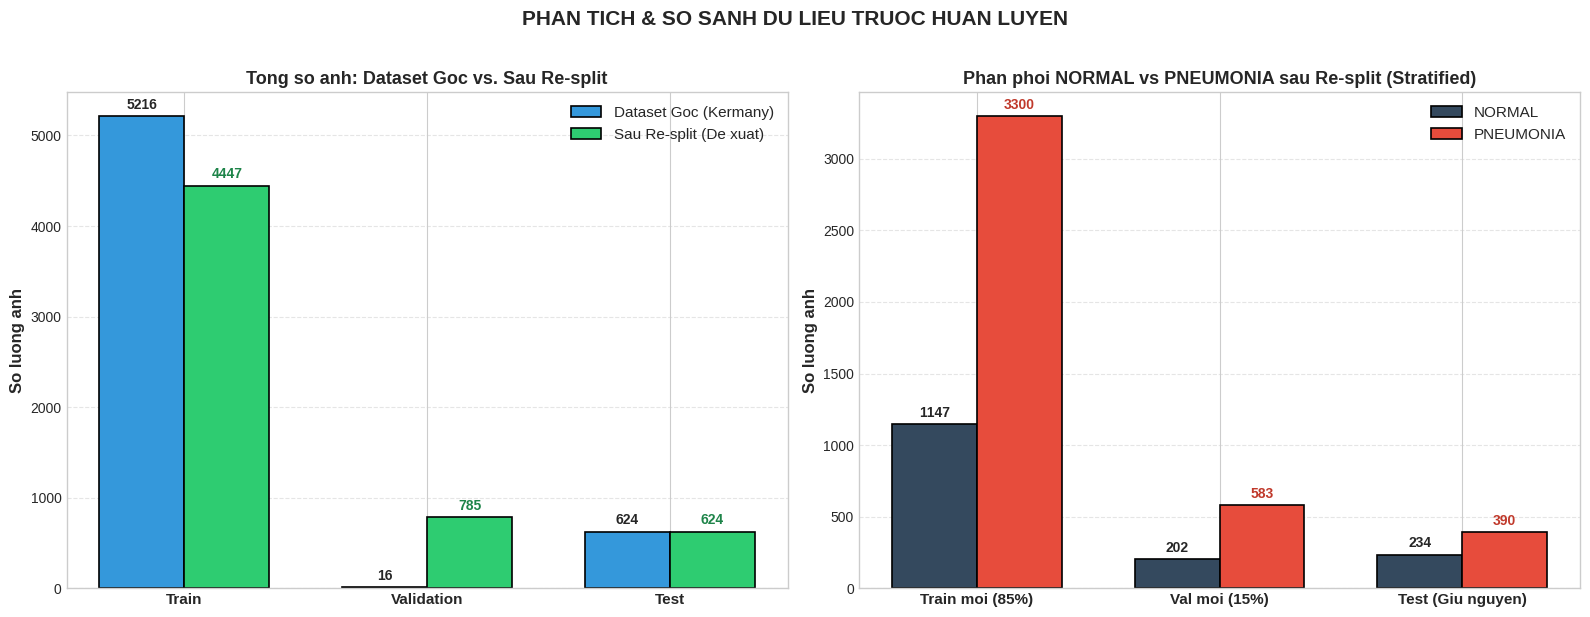

📊 Da xuat bieu do so sanh ra file: /content/dataset_split_comparison.png


In [20]:
# ===== 2. Bieu do truc quan hoa so sanh so lieu: Goc vs. Re-split =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: So sanh tong so anh tung tap (Goc vs Re-split)
splits_label = ['Train', 'Validation', 'Test']
orig_counts_list = [orig_train_total, orig_val_total, orig_test_total]
new_counts_list  = [new_train_total, new_val_total, new_test_total]

x = np.arange(len(splits_label))
width = 0.35

bars1 = axes[0].bar(x - width/2, orig_counts_list, width, label='Dataset Goc (Kermany)', color='#3498db', edgecolor='black', linewidth=1.2)
bars2 = axes[0].bar(x + width/2, new_counts_list, width, label='Sau Re-split (De xuat)', color='#2ecc71', edgecolor='black', linewidth=1.2)

axes[0].set_ylabel('So luong anh', fontsize=12, fontweight='bold')
axes[0].set_title('Tong so anh: Dataset Goc vs. Sau Re-split', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_label, fontsize=11, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Chu thich gia tri tren cot
for bar in bars1:
    h = bar.get_height()
    axes[0].annotate(f'{h}',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    axes[0].annotate(f'{h}',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1e8449')

# Subplot 2: Phan bo chi tiet NORMAL vs PNEUMONIA sau khi Re-split
subsets = ['Train moi (85%)', 'Val moi (15%)', 'Test (Giu nguyen)']
norms = [new_train_norm, new_val_norm, new_test_norm]
pneus = [new_train_pneu, new_val_pneu, new_test_pneu]

x2 = np.arange(len(subsets))
bars_norm = axes[1].bar(x2 - width/2, norms, width, label='NORMAL', color='#34495e', edgecolor='black', linewidth=1.2)
bars_pneu = axes[1].bar(x2 + width/2, pneus, width, label='PNEUMONIA', color='#e74c3c', edgecolor='black', linewidth=1.2)

axes[1].set_ylabel('So luong anh', fontsize=12, fontweight='bold')
axes[1].set_title('Phan phoi NORMAL vs PNEUMONIA sau Re-split (Stratified)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(subsets, fontsize=11, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_norm:
    h = bar.get_height()
    axes[1].annotate(f'{h}',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pneu:
    h = bar.get_height()
    axes[1].annotate(f'{h}',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c0392b')

plt.suptitle('PHAN TICH & SO SANH DU LIEU TRUOC HUAN LUYEN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/dataset_split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Da xuat bieu do so sanh ra file: /content/dataset_split_comparison.png')

In [21]:
# ===== 3. Kiem tra toan ven du lieu (Integrity & Anti-Leakage Check) =====
total_orig = orig_train_total + orig_val_total + orig_test_total
total_new  = new_train_total + new_val_total + new_test_total

# 1. Kiem tra bao toan tong so anh
assert total_orig == total_new, f'Loi bao toan: goc={total_orig}, moi={total_new}'
assert total_new == 5856, f'Tong so anh khong khop Kermany dataset (5856): {total_new}'

# 2. Kiem tra ty le class trong Train moi va Val moi
train_ratio = new_train_pneu / new_train_total
val_ratio   = new_val_pneu / new_val_total
diff = abs(train_ratio - val_ratio)
assert diff < 0.005, f'Do lech ty le lop vuot nguong: {diff}'

# 3. Kiem tra khong trung lap file (Data Leakage between Train and Val)
train_set = set(train_paths)
val_set   = set(val_paths)
leakage   = train_set.intersection(val_set)
assert len(leakage) == 0, f'Phat hien {len(leakage)} anh bi trung lap giua Train va Val!'

print('=' * 75)
print('KET QUA KIEM TRA TOAN VEN DU LIEU TRUOC HUAN LUYEN (DATA INTEGRITY CHECK):')
print(f'  [✓] Bao toan so luong: {total_new}/5856 anh (100% dung nguyen goc)')
print(f'  [✓] Ty le lop giua Train moi ({train_ratio*100:.2f}%) va Val moi ({val_ratio*100:.2f}%) chenh lech {diff*100:.3f}% (< 0.5%)')
print(f'  [✓] Kiem tra ro ri du lieu: 0 anh trung lap giua Train va Val')
print(f'  [✓] Tap Test doc lap (624 anh) duoc bao ve nguyen ven')
print('=' * 75)
print('>>> DATASET DA CHUAN HOA HOAN HAO, SAN SANG VAO HUAN LUYEN!')

KET QUA KIEM TRA TOAN VEN DU LIEU TRUOC HUAN LUYEN (DATA INTEGRITY CHECK):
  [✓] Bao toan so luong: 5856/5856 anh (100% dung nguyen goc)
  [✓] Ty le lop giua Train moi (74.21%) va Val moi (74.27%) chenh lech 0.060% (< 0.5%)
  [✓] Kiem tra ro ri du lieu: 0 anh trung lap giua Train va Val
  [✓] Tap Test doc lap (624 anh) duoc bao ve nguyen ven
>>> DATASET DA CHUAN HOA HOAN HAO, SAN SANG VAO HUAN LUYEN!


In [22]:
# ===== Custom Dataset class =====

class ChestXrayDataset(Dataset):
    """Custom Dataset cho Chest X-ray images.
    Doc anh tu danh sach paths, tu dong convert grayscale -> RGB,
    va apply transform.
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Mo anh va convert sang RGB (grayscale -> 3 channels)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


# Tao datasets
train_dataset = ChestXrayDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = ChestXrayDataset(val_paths, val_labels, transform=eval_transform)
test_dataset  = ImageFolder(str(TEST_DIR), transform=eval_transform)

print(f'Dataset sizes:')
print(f'   Train:      {len(train_dataset)}')
print(f'   Validation: {len(val_dataset)}')
print(f'   Test:       {len(test_dataset)}')

Dataset sizes:
   Train:      4447
   Validation: 785
   Test:       624


In [ ]:
# ===== DataLoaders =====

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f'DataLoaders da tao:')
print(f'   Train batches:  {len(train_loader)}')
print(f'   Val batches:    {len(val_loader)}')
print(f'   Test batches:   {len(test_loader)}')

# Kiem tra 1 batch
images, labels = next(iter(train_loader))
print(f'\n   Batch shape:  {images.shape}')
print(f'   Labels shape: {labels.shape}')
print(f'   Labels:       {labels[:10].tolist()}')

DataLoaders da tao:
   Train batches:  139
   Val batches:    25
   Test batches:   20

   Batch shape:  torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Labels:       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [24]:
# ===== Tinh class weights cho Weighted CrossEntropyLoss =====

class_count = Counter(train_labels)
total_samples = len(train_labels)

# Weight = total / (num_classes * count_per_class)
class_weights = torch.tensor([
    total_samples / (NUM_CLASSES * class_count[0]),
    total_samples / (NUM_CLASSES * class_count[1])
], dtype=torch.float32).to(DEVICE)

print(f'Class Weights (de xu ly mat can bang):')
print(f'   NORMAL (0):    {class_weights[0]:.4f}')
print(f'   PNEUMONIA (1): {class_weights[1]:.4f}')
print(f'\n   -> NORMAL co weight cao hon vi it mau hon')

Class Weights (de xu ly mat can bang):
   NORMAL (0):    1.9385
   PNEUMONIA (1): 0.6738

   -> NORMAL co weight cao hon vi it mau hon


---
## 4. Model Architecture: ResNet18

### Transfer Learning Strategy:
```
ResNet18 (pretrained ImageNet)
         |
  Replace final FC layer:
    512 -> 1000 (ImageNet)
         thanh
    512 -> 2   (NORMAL / PNEUMONIA)
         |
  Fine-tune toan bo model
```

In [25]:
def build_model(pretrained=True, num_classes=NUM_CLASSES):
    """
    Xay dung ResNet18 cho binary classification.

    Args:
        pretrained: True = dung ImageNet weights, False = train from scratch
        num_classes: so luong output classes

    Returns:
        model: ResNet18 da sua final layer
    """
    if pretrained:
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        print('Loaded ResNet18 with ImageNet pretrained weights')
    else:
        model = resnet18(weights=None)
        print('Initialized ResNet18 from scratch (random weights)')

    # Thay the lop fully connected cuoi cung
    # Original: nn.Linear(512, 1000) -> ImageNet 1000 classes
    # New:      nn.Linear(512, 2)    -> NORMAL / PNEUMONIA
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    print(f'   Input features:  {in_features}')
    print(f'   Output classes:  {num_classes}')

    # Dem parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'   Total params:     {total_params:,}')
    print(f'   Trainable params: {trainable_params:,}')

    return model.to(DEVICE)


# Xay dung model pretrained
print('=' * 50)
print('BUILDING MODEL')
print('=' * 50)
model = build_model(pretrained=True)

BUILDING MODEL
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]

Loaded ResNet18 with ImageNet pretrained weights
   Input features:  512
   Output classes:  2
   Total params:     11,177,538
   Trainable params: 11,177,538


In [26]:
# ===== Xem kien truc model =====
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
# ===== Loss function & Optimizer =====

# Weighted CrossEntropyLoss -- xu ly class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler: giam lr khi val_loss khong cai thien
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print(f'Loss: Weighted CrossEntropyLoss')
print(f'Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)')

Loss: Weighted CrossEntropyLoss
Optimizer: AdamW (lr=0.0001, wd=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


---
## 5. Training

In [29]:
# ===== Training & Validation Functions =====

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train model cho 1 epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Thong ke
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Evaluate model tren validation/test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validating', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [30]:
# ===== Training Loop voi Early Stopping =====

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, patience, device, model_name='resnet18_pretrained'):
    """
    Training loop hoan chinh voi early stopping.

    Returns:
        model: model voi best weights
        history: dict chua loss & accuracy theo epoch
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    best_epoch = 0

    print('=' * 70)
    print(f'TRAINING: {model_name}')
    print(f'   Epochs: {num_epochs} | Early Stopping patience: {patience}')
    print('=' * 70)

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_acc = validate(
            model, val_loader, criterion, device
        )

        # Scheduler step
        scheduler.step(val_loss)

        # Luu history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_no_improve = 0
            marker = '  << Best'
        else:
            epochs_no_improve += 1
            marker = f'  No improve ({epochs_no_improve}/{patience})'

        print(f'Epoch [{epoch+1:>2}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'LR: {current_lr:.6f} | '
              f'{epoch_time:.1f}s{marker}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch+1}!')
            break

    total_time = time.time() - start_time

    # Load best weights
    model.load_state_dict(best_model_weights)

    print(f'\n{"=" * 70}')
    print(f'Training hoan tat trong {total_time:.1f}s')
    print(f'   Best epoch: {best_epoch}')
    print(f'   Best val loss: {best_val_loss:.4f}')
    print(f'{"=" * 70}')

    # Save model
    save_path = f'/content/{model_name}_best.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'history': history
    }, save_path)
    print(f'Model saved to {save_path}')

    return model, history

In [32]:
# ===== BAT DAU TRAINING =====
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    device=DEVICE,
    model_name='resnet18_pretrained'
)

TRAINING: resnet18_pretrained
   Epochs: 15 | Early Stopping patience: 4


Training:   0%|          | 0/139 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch [ 1/15] Train Loss: 0.0512 Acc: 0.9789 | Val Loss: 0.0524 Acc: 0.9707 | LR: 0.000100 | 89.1s  << Best


Training:   0%|          | 0/139 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch [ 6/15] Train Loss: 0.0309 Acc: 0.9892 | Val Loss: 0.0960 Acc: 0.9554 | LR: 0.000050 | 90.8s  No improve (3/4)


Training:   0%|          | 0/139 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch [ 7/15] Train Loss: 0.0355 Acc: 0.9894 | Val Loss: 0.0491 Acc: 0.9758 | LR: 0.000050 | 88.7s  No improve (4/4)

Early stopping triggered at epoch 7!

Training hoan tat trong 625.7s
   Best epoch: 3
   Best val loss: 0.0356
Model saved to /content/resnet18_pretrained_best.pth


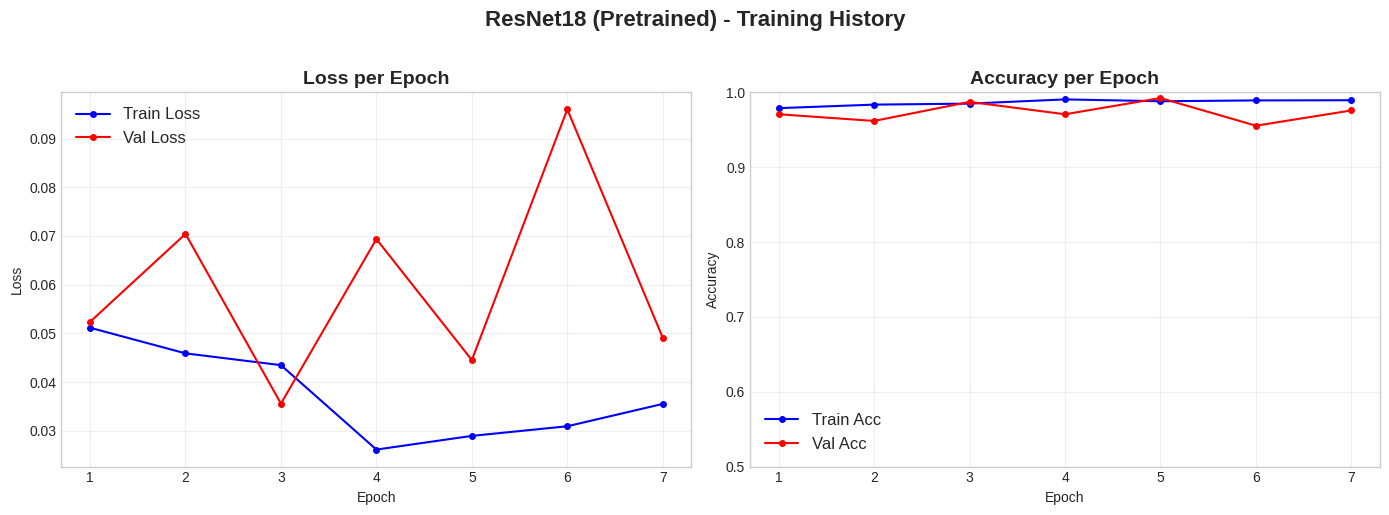

In [33]:
# ===== Ve Training Curves =====

def plot_training_history(history, title='Training History'):
    """Ve bieu do loss va accuracy theo epoch."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
    ax1.set_title('Loss per Epoch', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Acc', markersize=4)
    ax2.set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0.5, 1.0])

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history, 'ResNet18 (Pretrained) - Training History')

---
## 6. Evaluation on Test Set

In [34]:
# ===== Comprehensive Evaluation Function =====

def evaluate_model(model, dataloader, device, class_names=CLASS_NAMES,
                   save_prefix='pretrained'):
    """
    Danh gia model toan dien tren test set.

    Returns:
        results: dict chua tat ca metrics
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Testing'):
            images = images.to(device)
            outputs = model(images)

            # Probabilities qua softmax
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # ===== Tinh metrics =====
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, pos_label=1)
    recall = recall_score(all_labels, all_preds, pos_label=1)  # Sensitivity
    f1 = f1_score(all_labels, all_preds, pos_label=1)

    # Specificity: TN / (TN + FP)
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # ROC-AUC: dung probability cua class PNEUMONIA (class 1)
    roc_auc = roc_auc_score(all_labels, all_probs[:, 1])

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall_sensitivity': recall,
        'specificity': specificity,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'all_labels': all_labels,
        'all_preds': all_preds,
        'all_probs': all_probs
    }

    # ===== In ket qua =====
    print(f'\n{"=" * 60}')
    print(f'TEST SET EVALUATION RESULTS ({save_prefix})')
    print(f'{"=" * 60}')
    print(f'  Accuracy:              {accuracy:.4f}  ({accuracy*100:.2f}%)')
    print(f'  Precision:             {precision:.4f}  ({precision*100:.2f}%)')
    print(f'  Recall / Sensitivity:  {recall:.4f}  ({recall*100:.2f}%)')
    print(f'  Specificity:           {specificity:.4f}  ({specificity*100:.2f}%)')
    print(f'  F1-Score:              {f1:.4f}  ({f1*100:.2f}%)')
    print(f'  ROC-AUC:               {roc_auc:.4f}  ({roc_auc*100:.2f}%)')
    print(f'{"=" * 60}')

    print(f'\n  Confusion Matrix:')
    print(f'  {"":>20s} Predicted')
    print(f'  {"":>15s} {"NORMAL":>10s} {"PNEUMONIA":>10s}')
    print(f'  Actual NORMAL    {tn:>10d} {fp:>10d}')
    print(f'  Actual PNEUMONIA {fn:>10d} {tp:>10d}')
    print(f'\n  TP={tp}, TN={tn}, FP={fp}, FN={fn}')

    # ===== Classification Report =====
    print(f'\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names, digits=4))

    return results

In [35]:
# ===== Danh gia model pretrained tren Test Set =====
results_pretrained = evaluate_model(
    model, test_loader, DEVICE,
    save_prefix='pretrained'
)

Testing:   0%|          | 0/20 [00:00<?, ?it/s]


TEST SET EVALUATION RESULTS (pretrained)
  Accuracy:              0.8558  (85.58%)
  Precision:             0.8151  (81.51%)
  Recall / Sensitivity:  0.9949  (99.49%)
  Specificity:           0.6239  (62.39%)
  F1-Score:              0.8961  (89.61%)
  ROC-AUC:               0.9701  (97.01%)

  Confusion Matrix:
                       Predicted
                      NORMAL  PNEUMONIA
  Actual NORMAL           146         88
  Actual PNEUMONIA          2        388

  TP=388, TN=146, FP=88, FN=2

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9865    0.6239    0.7644       234
   PNEUMONIA     0.8151    0.9949    0.8961       390

    accuracy                         0.8558       624
   macro avg     0.9008    0.8094    0.8302       624
weighted avg     0.8794    0.8558    0.8467       624



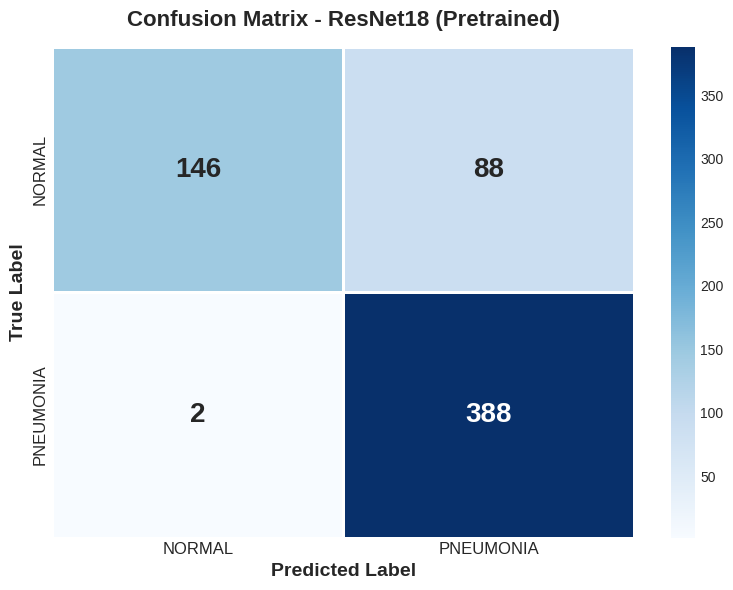

In [36]:
# ===== Ve Confusion Matrix =====

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix',
                          save_path=None):
    """Ve confusion matrix."""
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={'size': 20, 'fontweight': 'bold'},
        linewidths=2,
        linecolor='white',
        ax=ax
    )

    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(labelsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(
    results_pretrained['confusion_matrix'],
    CLASS_NAMES,
    title='Confusion Matrix - ResNet18 (Pretrained)',
    save_path='/content/confusion_matrix_pretrained.png'
)

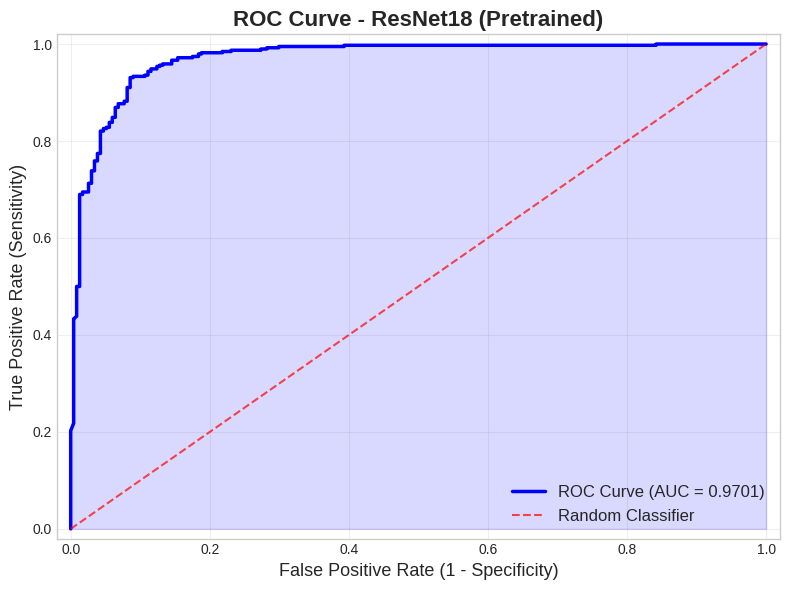

np.float64(0.9700964277887355)

In [37]:
# ===== Ve ROC Curve =====

def plot_roc_curve(labels, probs, title='ROC Curve', save_path=None):
    """Ve ROC curve va tinh AUC."""
    fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
    auc = roc_auc_score(labels, probs[:, 1])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC Curve (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, alpha=0.7, label='Random Classifier')

    ax.fill_between(fpr, tpr, alpha=0.15, color='blue')

    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=13)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return auc

plot_roc_curve(
    results_pretrained['all_labels'],
    results_pretrained['all_probs'],
    title='ROC Curve - ResNet18 (Pretrained)',
    save_path='/content/roc_curve_pretrained.png'
)

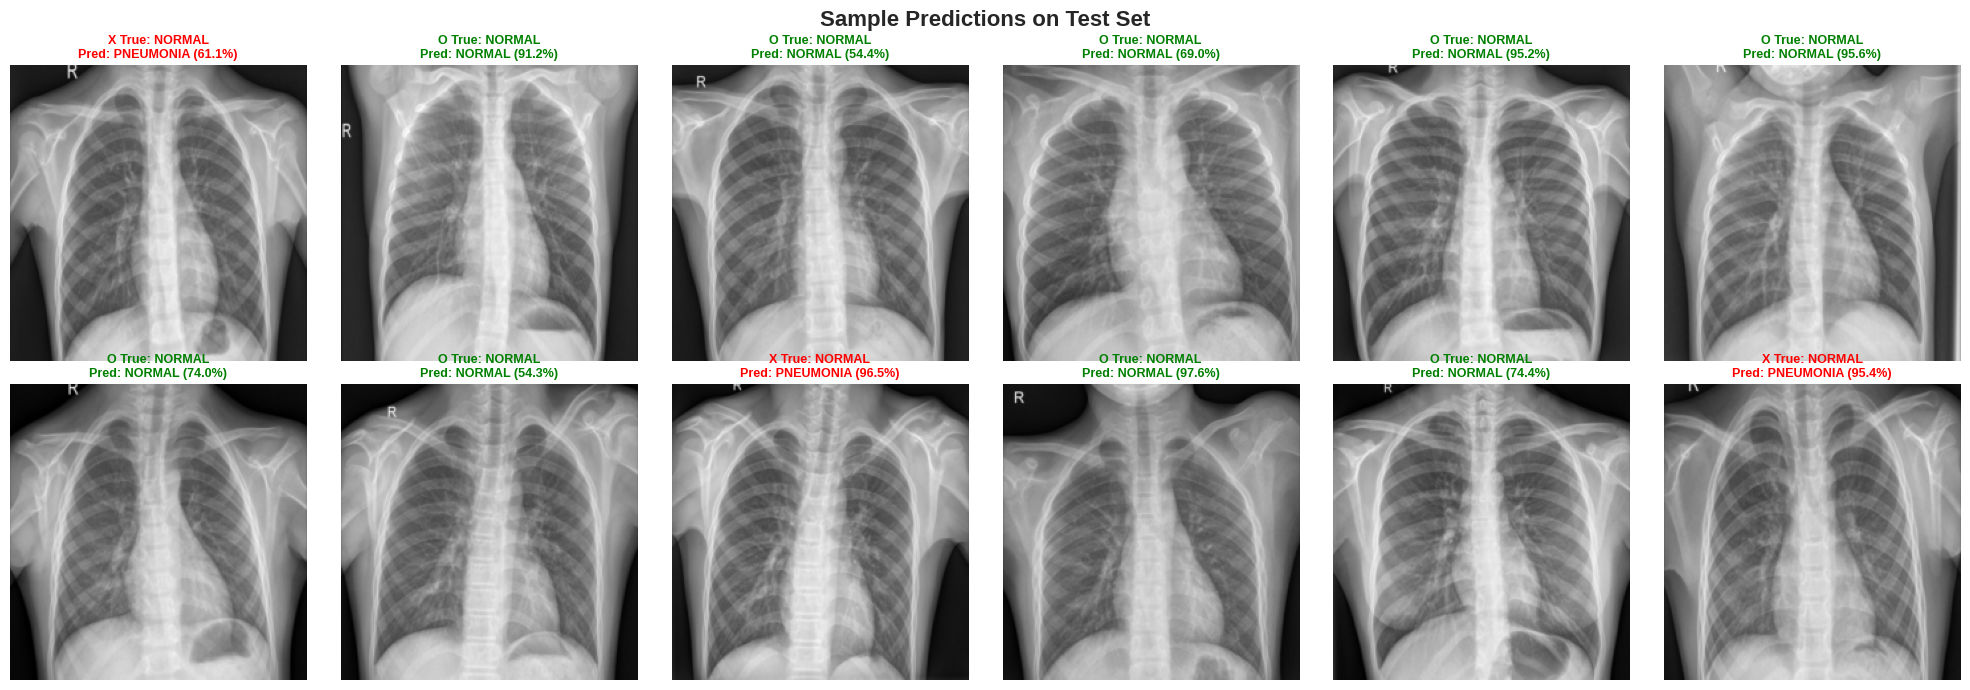

In [38]:
# ===== Hien thi anh du doan mau =====

def show_predictions(model, dataloader, device, class_names, n=12):
    """Hien thi n anh voi prediction va ground truth."""
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    axes = axes.flatten()

    # ImageNet denormalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    with torch.no_grad():
        for images, labels in dataloader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= n:
                    break

                # Denormalize anh
                img = images[i].cpu() * std + mean
                img = img.clamp(0, 1)
                img = img.permute(1, 2, 0).numpy()

                true_label = class_names[labels[i]]
                pred_label = class_names[preds[i].cpu()]
                confidence = probs[i][preds[i].cpu()].item()

                ax = axes[images_shown]
                ax.imshow(img)
                ax.axis('off')

                # Mau: xanh neu dung, do neu sai
                color = 'green' if true_label == pred_label else 'red'
                symbol = 'O' if true_label == pred_label else 'X'

                ax.set_title(
                    f'{symbol} True: {true_label}\nPred: {pred_label} ({confidence:.1%})',
                    fontsize=9, color=color, fontweight='bold'
                )
                images_shown += 1

            if images_shown >= n:
                break

    plt.suptitle('Sample Predictions on Test Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(model, test_loader, DEVICE, CLASS_NAMES)

---
## 7. Experiment: Pretrained vs. From Scratch

**Research Question:**
> How does transfer learning affect pneumonia classification performance compared with training ResNet18 from scratch?

In [40]:
# ===== Experiment 2: ResNet18 from scratch =====
seed_everything(SEED)

print('\n' + '#' * 70)
print('#  EXPERIMENT 2: ResNet18 FROM SCRATCH (No Pretrained Weights)')
print('#' * 70 + '\n')

# Build model WITHOUT pretrained weights
model_scratch = build_model(pretrained=False)

# Cung loss, optimizer, scheduler
criterion_scratch = nn.CrossEntropyLoss(weight=class_weights)
optimizer_scratch = optim.AdamW(
    model_scratch.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
scheduler_scratch = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_scratch, mode='min', factor=0.5, patience=2
)


######################################################################
#  EXPERIMENT 2: ResNet18 FROM SCRATCH (No Pretrained Weights)
######################################################################

Initialized ResNet18 from scratch (random weights)
   Input features:  512
   Output classes:  2
   Total params:     11,177,538
   Trainable params: 11,177,538


In [41]:
# Train from scratch
model_scratch, history_scratch = train_model(
    model=model_scratch,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_scratch,
    optimizer=optimizer_scratch,
    scheduler=scheduler_scratch,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    device=DEVICE,
    model_name='resnet18_scratch'
)

TRAINING: resnet18_scratch
   Epochs: 15 | Early Stopping patience: 4


Training:   0%|          | 0/139 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:10<?, ?it/s]

Epoch [ 1/15] Train Loss: 0.2625 Acc: 0.8945 | Val Loss: 0.1426 Acc: 0.9185 | LR: 0.000100 | 95.6s  << Best


Training:   0%|          | 0/139 [00:00<?, ?it/s]

...

Training:   0%|          | 0/139 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b2263c6fc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x79b2263c6fc0> 
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    ^if w.is_alive():^

    File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'  
   ^ ^ ^ ^ ^ ^^ ^ ^ ^ ^^^^^
^  File "

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b2263c6fc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x79b2263c6fc0> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    if w.is_alive():^
^ ^ ^ ^  ^  ^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^^assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^ ^ ^ ^ 
    File "/usr/lib

Epoch [ 7/15] Train Loss: 0.0850 Acc: 0.9696 | Val Loss: 0.0848 Acc: 0.9580 | LR: 0.000050 | 98.4s  No improve (4/4)

Early stopping triggered at epoch 7!

Training hoan tat trong 645.7s
   Best epoch: 3
   Best val loss: 0.0735
Model saved to /content/resnet18_scratch_best.pth


In [43]:
# Evaluate from-scratch model
results_scratch = evaluate_model(
    model_scratch, test_loader, DEVICE,
    save_prefix='scratch'
)

Testing:   0%|          | 0/20 [00:00<?, ?it/s]


TEST SET EVALUATION RESULTS (scratch)
  Accuracy:              0.8141  (81.41%)
  Precision:             0.7740  (77.40%)
  Recall / Sensitivity:  0.9923  (99.23%)
  Specificity:           0.5171  (51.71%)
  F1-Score:              0.8697  (86.97%)
  ROC-AUC:               0.9448  (94.48%)

  Confusion Matrix:
                       Predicted
                      NORMAL  PNEUMONIA
  Actual NORMAL           121        113
  Actual PNEUMONIA          3        387

  TP=387, TN=121, FP=113, FN=3

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9758    0.5171    0.6760       234
   PNEUMONIA     0.7740    0.9923    0.8697       390

    accuracy                         0.8141       624
   macro avg     0.8749    0.7547    0.7728       624
weighted avg     0.8497    0.8141    0.7970       624



In [44]:
# ===== So sanh 2 experiments =====

print('\n' + '=' * 70)
print('COMPARISON: Pretrained vs. From Scratch')
print('=' * 70)

metrics_names = [
    ('Accuracy',             'accuracy'),
    ('Precision',            'precision'),
    ('Recall/Sensitivity',   'recall_sensitivity'),
    ('Specificity',          'specificity'),
    ('F1-Score',             'f1_score'),
    ('ROC-AUC',              'roc_auc'),
]

print(f'\n{"Metric":<25s} {"Pretrained":>12s} {"From Scratch":>14s} {"Delta":>10s}')
print('-' * 65)

comparison_data = []
for display_name, key in metrics_names:
    val_pre = results_pretrained[key]
    val_scr = results_scratch[key]
    diff = val_pre - val_scr
    sign = '+' if diff >= 0 else ''
    print(f'{display_name:<25s} {val_pre:>11.4f} {val_scr:>13.4f} {sign}{diff:>9.4f}')
    comparison_data.append({
        'Metric': display_name,
        'Pretrained': val_pre,
        'From Scratch': val_scr,
        'Difference': diff
    })

print('-' * 65)


COMPARISON: Pretrained vs. From Scratch

Metric                      Pretrained   From Scratch      Delta
-----------------------------------------------------------------
Accuracy                       0.8558        0.8141 +   0.0417
Precision                      0.8151        0.7740 +   0.0411
Recall/Sensitivity             0.9949        0.9923 +   0.0026
Specificity                    0.6239        0.5171 +   0.1068
F1-Score                       0.8961        0.8697 +   0.0264
ROC-AUC                        0.9701        0.9448 +   0.0253
-----------------------------------------------------------------


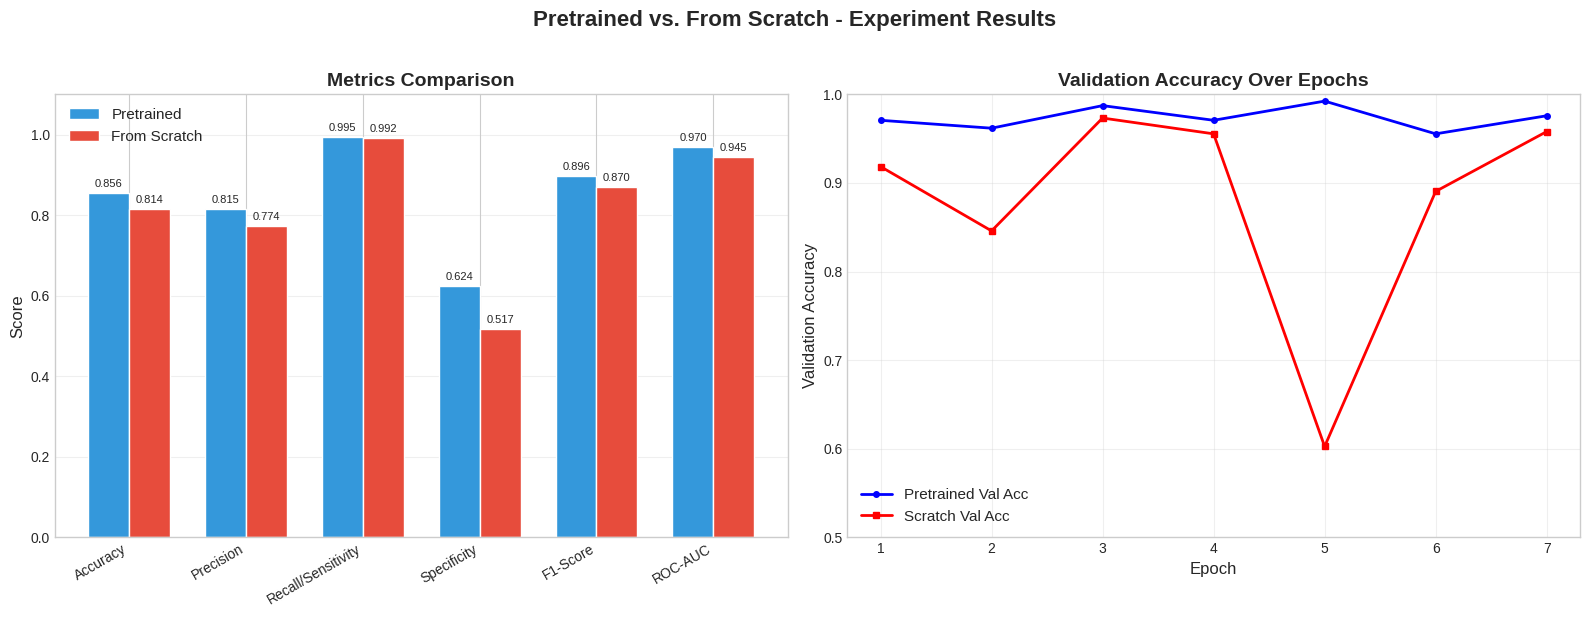

In [45]:
# ===== Bieu do so sanh =====

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: So sanh metrics ---
df_compare = pd.DataFrame(comparison_data)
x = np.arange(len(df_compare))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_compare['Pretrained'], width,
                     label='Pretrained', color='#3498db', edgecolor='white')
bars2 = axes[0].bar(x + width/2, df_compare['From Scratch'], width,
                     label='From Scratch', color='#e74c3c', edgecolor='white')

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_compare['Metric'], rotation=30, ha='right', fontsize=10)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1.1])
axes[0].grid(True, axis='y', alpha=0.3)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# --- Plot 2: Training curves so sanh ---
epochs_pre = range(1, len(history['val_acc']) + 1)
epochs_scr = range(1, len(history_scratch['val_acc']) + 1)

axes[1].plot(epochs_pre, history['val_acc'], 'b-o', label='Pretrained Val Acc',
             markersize=4, linewidth=2)
axes[1].plot(epochs_scr, history_scratch['val_acc'], 'r-s', label='Scratch Val Acc',
             markersize=4, linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.5, 1.0])

plt.suptitle('Pretrained vs. From Scratch - Experiment Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

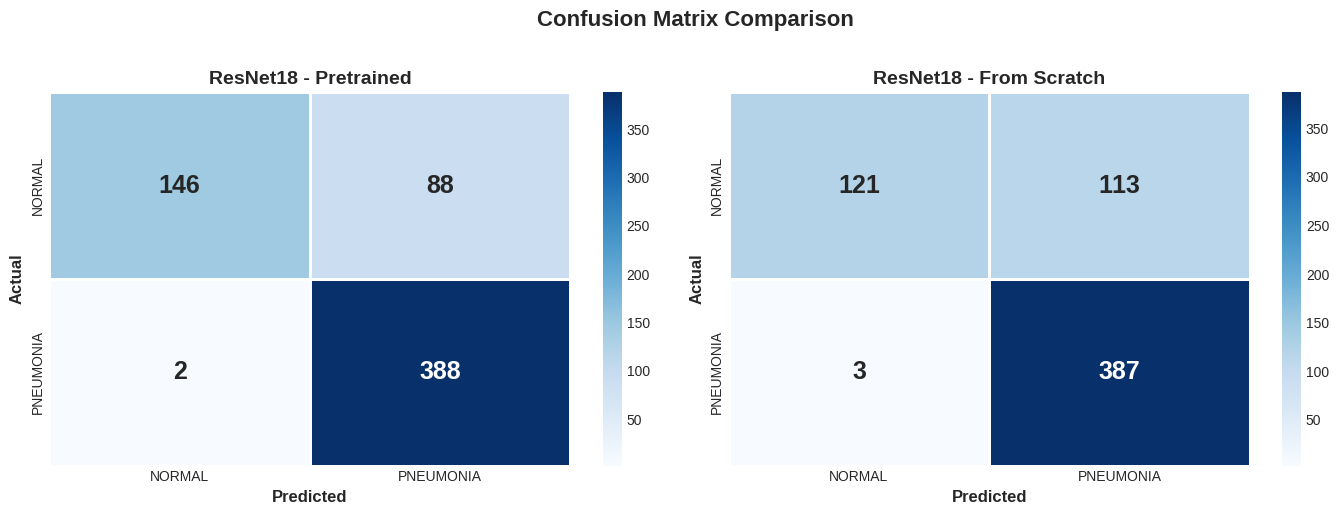

In [46]:
# ===== Confusion Matrices canh nhau =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in [
    (ax1, results_pretrained['confusion_matrix'], 'Pretrained'),
    (ax2, results_scratch['confusion_matrix'], 'From Scratch')
]:
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={'size': 18, 'fontweight': 'bold'},
        linewidths=2, linecolor='white', ax=ax
    )
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title(f'ResNet18 - {title}', fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===== ROC Curves so sanh =====

fig, ax = plt.subplots(figsize=(8, 6))

for results, label, color in [
    (results_pretrained, 'Pretrained', '#3498db'),
    (results_scratch, 'From Scratch', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(results['all_labels'], results['all_probs'][:, 1])
    auc = results['roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{label} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Pretrained vs. From Scratch', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Error Analysis (Phan tich loi)

Phan tich cac truong hop model du doan sai:
- **False Positive (FP):** NORMAL -> du doan PNEUMONIA
- **False Negative (FN):** PNEUMONIA -> du doan NORMAL (nguy hiem hon trong y khoa)

In [47]:
# ===== Tim va hien thi cac truong hop du doan sai =====

model.eval()
fp_images, fp_info = [], []
fn_images, fn_info = [], []

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu()

        for i in range(images.size(0)):
            true = labels[i].item()
            pred = preds[i].item()
            conf = probs[i][pred].item()

            if true == 0 and pred == 1:  # FP
                img = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
                fp_images.append(img)
                fp_info.append(conf)
            elif true == 1 and pred == 0:  # FN
                img = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
                fn_images.append(img)
                fn_info.append(conf)

print(f'False Positives (NORMAL -> predicted PNEUMONIA): {len(fp_images)}')
print(f'False Negatives (PNEUMONIA -> predicted NORMAL): {len(fn_images)}')
print(f'\nWARNING: FN (False Negative) la loi nguy hiem nhat trong y khoa:')
print(f'   Benh nhan viem phoi bi bo sot!')

False Positives (NORMAL -> predicted PNEUMONIA): 88
False Negatives (PNEUMONIA -> predicted NORMAL): 2

   Benh nhan viem phoi bi bo sot!


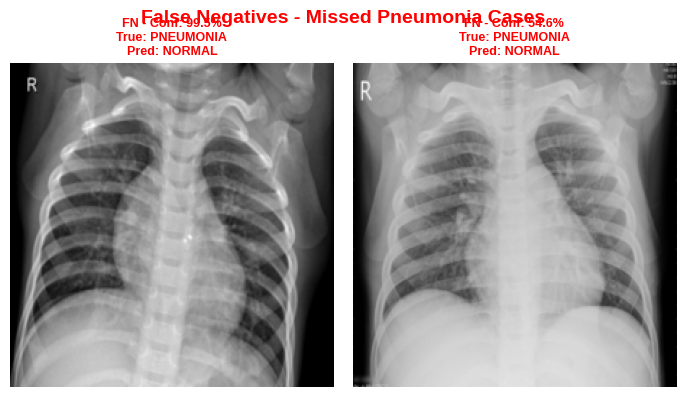

In [48]:
# ===== Hien thi False Negatives =====
n_show = min(6, len(fn_images))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        axes[i].imshow(fn_images[i])
        axes[i].set_title(f'FN - Conf: {fn_info[i]:.1%}\nTrue: PNEUMONIA\nPred: NORMAL',
                          fontsize=9, color='red', fontweight='bold')
        axes[i].axis('off')
    plt.suptitle('False Negatives - Missed Pneumonia Cases',
                 fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('/content/false_negatives.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Khong co False Negative tren test set!')

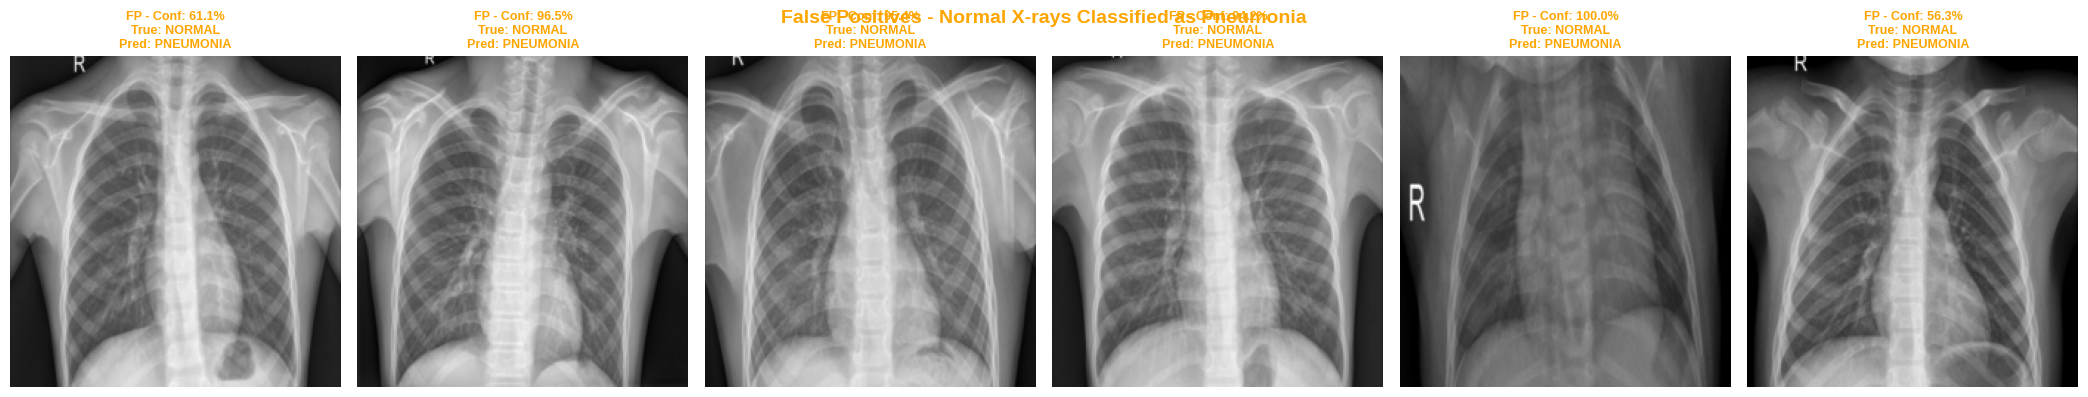

In [49]:
# ===== Hien thi False Positives =====
n_show = min(6, len(fp_images))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        axes[i].imshow(fp_images[i])
        axes[i].set_title(f'FP - Conf: {fp_info[i]:.1%}\nTrue: NORMAL\nPred: PNEUMONIA',
                          fontsize=9, color='orange', fontweight='bold')
        axes[i].axis('off')
    plt.suptitle('False Positives - Normal X-rays Classified as Pneumonia',
                 fontsize=14, fontweight='bold', color='orange')
    plt.tight_layout()
    plt.savefig('/content/false_positives.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Khong co False Positive tren test set!')

---
## 9. Tong ket & Ket luan

In [50]:
# ===== Final Summary =====

print('\n' + '=' * 70)
print('FINAL SUMMARY')
print('=' * 70)

print(f'''
Title:
  Pneumonia Classification from Chest X-ray Images
  Using Transfer Learning with ResNet18

Dataset:
  Kermany Chest X-ray Pneumonia Dataset
  Source: Kaggle / Mendeley Data
  Classes: NORMAL, PNEUMONIA

Model:
  ResNet18 (ImageNet pretrained) - Fine-tuned
  Parameters: ~11.7M

Training Configuration:
  Input:      224 x 224 x 3 (RGB)
  Batch size: {BATCH_SIZE}
  Epochs:     {NUM_EPOCHS} (with early stopping, patience={PATIENCE})
  Optimizer:  AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})
  Loss:       Weighted CrossEntropyLoss

Experiment 1 - Pretrained (Transfer Learning):
  Accuracy:     {results_pretrained['accuracy']:.4f}
  Precision:    {results_pretrained['precision']:.4f}
  Sensitivity:  {results_pretrained['recall_sensitivity']:.4f}
  Specificity:  {results_pretrained['specificity']:.4f}
  F1-Score:     {results_pretrained['f1_score']:.4f}
  ROC-AUC:      {results_pretrained['roc_auc']:.4f}

Experiment 2 - From Scratch:
  Accuracy:     {results_scratch['accuracy']:.4f}
  Precision:    {results_scratch['precision']:.4f}
  Sensitivity:  {results_scratch['recall_sensitivity']:.4f}
  Specificity:  {results_scratch['specificity']:.4f}
  F1-Score:     {results_scratch['f1_score']:.4f}
  ROC-AUC:      {results_scratch['roc_auc']:.4f}

Conclusion:
  Transfer learning with ImageNet pretrained weights significantly
  improves pneumonia classification performance compared to
  training from scratch, demonstrating the effectiveness of
  leveraging pre-learned low-level features for medical image
  classification tasks.
''')


FINAL SUMMARY

Title:
  Pneumonia Classification from Chest X-ray Images
  Using Transfer Learning with ResNet18

Dataset:
  Kermany Chest X-ray Pneumonia Dataset
  Source: Kaggle / Mendeley Data
  Classes: NORMAL, PNEUMONIA

Model:
  ResNet18 (ImageNet pretrained) - Fine-tuned
  Parameters: ~11.7M

Training Configuration:
  Input:      224 x 224 x 3 (RGB)
  Batch size: 32
  Epochs:     15 (with early stopping, patience=4)
  Optimizer:  AdamW (lr=0.0001, wd=0.0001)
  Loss:       Weighted CrossEntropyLoss

Experiment 1 - Pretrained (Transfer Learning):
  Accuracy:     0.8558
  Precision:    0.8151
  Sensitivity:  0.9949
  Specificity:  0.6239
  F1-Score:     0.8961
  ROC-AUC:      0.9701

Experiment 2 - From Scratch:
  Accuracy:     0.8141
  Precision:    0.7740
  Sensitivity:  0.9923
  Specificity:  0.5171
  F1-Score:     0.8697
  ROC-AUC:      0.9448

Conclusion:
  Transfer learning with ImageNet pretrained weights significantly
  improves pneumonia classification performance compare

In [51]:
# ===== Save summary metrics to CSV =====

df_results = pd.DataFrame({
    'Metric': [m[0] for m in metrics_names],
    'Pretrained': [results_pretrained[m[1]] for m in metrics_names],
    'From_Scratch': [results_scratch[m[1]] for m in metrics_names],
})
df_results['Difference'] = df_results['Pretrained'] - df_results['From_Scratch']

df_results.to_csv('/content/experiment_results.csv', index=False)
print('Results saved to /content/experiment_results.csv')
print('\n')
print(df_results.to_string(index=False))

Results saved to /content/experiment_results.csv


            Metric  Pretrained  From_Scratch  Difference
          Accuracy    0.855769      0.814103    0.041667
         Precision    0.815126      0.774000    0.041126
Recall/Sensitivity    0.994872      0.992308    0.002564
       Specificity    0.623932      0.517094    0.106838
          F1-Score    0.896074      0.869663    0.026411
           ROC-AUC    0.970096      0.944762    0.025334


In [53]:
# ===== Liet ke tat ca files da luu =====
import os

saved_files = [
    'resnet18_pretrained_best.pth',
    'resnet18_scratch_best.pth',
    'dataset_split_comparison.png',
    'split_comparison_before_after.csv',
    'class_distribution.png',
    'sample_images.png',
    'training_history.png',
    'confusion_matrix_pretrained.png',
    'roc_curve_pretrained.png',
    'sample_predictions.png',
    'comparison_results.png',
    'confusion_matrices_comparison.png',
    'roc_curves_comparison.png',
    'false_negatives.png',
    'false_positives.png',
    'experiment_results.csv',
]

print('Tat ca files output:')
for f in saved_files:
    path = f'/content/{f}'
    exists = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{exists}] {path}')

print('\nTip: Download tat ca anh de dua vao bao cao!')
print('  Tren Colab: Files (panel trai) -> Right-click -> Download')


Tat ca files output:
  [OK] /content/resnet18_pretrained_best.pth
  [OK] /content/resnet18_scratch_best.pth
  [OK] /content/dataset_split_comparison.png
  [OK] /content/split_comparison_before_after.csv
  [OK] /content/class_distribution.png
  [OK] /content/sample_images.png
  [OK] /content/training_history.png
  [OK] /content/confusion_matrix_pretrained.png
  [OK] /content/roc_curve_pretrained.png
  [OK] /content/sample_predictions.png
  [OK] /content/comparison_results.png
  [OK] /content/confusion_matrices_comparison.png
  [MISSING] /content/roc_curves_comparison.png
  [OK] /content/false_negatives.png
  [OK] /content/false_positives.png
  [OK] /content/experiment_results.csv

Tip: Download tat ca anh de dua vao bao cao!
  Tren Colab: Files (panel trai) -> Right-click -> Download


In [54]:
import os
import shutil
from google.colab import drive

# Bước 1: Mount Drive (Colab sẽ hiện popup yêu cầu cấp quyền, bạn chọn Cho phép)
drive.mount('/content/drive')

# Bước 2: Tạo thư mục lưu trên Drive
target_dir = '/content/drive/MyDrive/CT223H_Pneumonia_Project'
os.makedirs(target_dir, exist_ok=True)

# Bước 3: Copy toàn bộ file kết quả (.pth, .png, .csv) sang Drive
for f in os.listdir('/content'):
    if f.endswith(('.pth', '.png', '.csv')):
        src = os.path.join('/content', f)
        dst = os.path.join(target_dir, f)
        shutil.copy(src, dst)
        print(f"-> Đã lưu lên Drive: {f}")

print("\n Xong! Toàn bộ kết quả đã được lưu an toàn trên Google Drive.")


Mounted at /content/drive
-> Đã lưu lên Drive: resnet18_pretrained_best.pth
-> Đã lưu lên Drive: false_negatives.png
-> Đã lưu lên Drive: false_positives.png
-> Đã lưu lên Drive: sample_predictions.png
-> Đã lưu lên Drive: resnet18_scratch_best.pth
-> Đã lưu lên Drive: class_distribution.png
-> Đã lưu lên Drive: training_history.png
-> Đã lưu lên Drive: split_comparison_before_after.csv
-> Đã lưu lên Drive: experiment_results.csv
-> Đã lưu lên Drive: roc_curve_pretrained.png
-> Đã lưu lên Drive: confusion_matrices_comparison.png
-> Đã lưu lên Drive: sample_images.png
-> Đã lưu lên Drive: confusion_matrix_pretrained.png
-> Đã lưu lên Drive: comparison_results.png
-> Đã lưu lên Drive: dataset_split_comparison.png

 Xong! Toàn bộ kết quả đã được lưu an toàn trên Google Drive.


---

## Ghi chu cho Bao cao

### Cac hinh anh can dua vao bao cao:
1. `class_distribution.png` - Phan phoi class trong dataset
2. `dataset_split_comparison.png` - So sánh số liệu dataset gốc vs sau khi re-split
2. `sample_images.png` - Anh X-ray mau
3. `training_history.png` - Bieu do loss/accuracy theo epoch
4. `confusion_matrix_pretrained.png` - Confusion matrix (pretrained)
5. `roc_curve_pretrained.png` - ROC curve (pretrained)
6. `sample_predictions.png` - Anh du doan mau
7. `comparison_results.png` - So sanh Pretrained vs From Scratch
8. `confusion_matrices_comparison.png` - Confusion matrices so sanh
9. `roc_curves_comparison.png` - ROC curves so sanh
10. `false_negatives.png` - Cac ca FN (bo sot pneumonia)
11. `false_positives.png` - Cac ca FP (duong tinh gia)

### Cau truc bao cao goi y:
1. **Introduction** - Gioi thieu bai toan, tai sao can AI trong chan doan
2. **Related Work** - Transfer learning trong medical imaging
3. **Dataset** - Mo ta Kermany dataset, class distribution
4. **Methodology** - ResNet18, transfer learning, preprocessing
5. **Experiments** - Pretrained vs From Scratch
6. **Results** - Metrics, confusion matrix, ROC curve
7. **Error Analysis** - Phan tich FP/FN
8. **Conclusion** - Ket luan, han che, huong phat trien

---
*CT223H - Nen tang tri tue nhan tao*